In [1]:
# --- cell 1: imports --- 
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from torch.amp import autocast
import sys
sys.path.insert(0, '/home/vteam2/ayesha_xbd')

from dataset import get_dataloaders
from damage_ensemble import load_ensemble, ensemble_predict

/home/vteam2/anaconda3/envs/ayesha_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- cell 2: configs --- 

PREPROCESSED_DIR = '/home/vteam2/ayesha_xbd/preprocessed'
SAVE_DIR         = Path('/home/vteam2/ayesha_xbd/checkpoints/ensemble')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

UNET_CKPT      = '/home/vteam2/ayesha_xbd/checkpoints/siamese_unet_run4/best_siamese_unet_run4.pth'
DEEPLAB_CKPT   = '/home/vteam2/ayesha_xbd/checkpoints/siamese_deeplab_base/best_siamese_deeplabv3.pth'
SEGFORMER_CKPT = '/home/vteam2/ayesha_xbd/checkpoints/segformer_run1/best_segformer_run1.pth'

NUM_CLASSES  = 4
BATCH_SIZE   = 8
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES  = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']

print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# --- cell 3: load models --- 

# load all 3 models from their best checkpoints
unet, deeplab, segformer = load_ensemble(
    UNET_CKPT, DEEPLAB_CKPT, SEGFORMER_CKPT,
    num_classes=NUM_CLASSES,
    device=DEVICE
)

Loading Siamese U-Net...
Loading Siamese DeepLabV3+...
Loading SegFormer...


[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 364/364 [00:00<00:00, 27009.28it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
dec

All models loaded!


In [4]:
# --- cell 4: metric fucntions --- 
# same metrics as individual model testing

def calculate_metrics(preds, masks, num_classes=NUM_CLASSES):

    preds = torch.argmax(preds, dim=1)
    preds = preds.cpu().numpy().flatten()
    masks = masks.cpu().numpy().flatten()

    pixel_acc     = (preds == masks).mean()
    iou_per_class = []
    f1_per_class  = []

    for c in range(num_classes):
        pred_c       = (preds == c)
        true_c       = (masks == c)
        intersection = (pred_c & true_c).sum()
        union        = (pred_c | true_c).sum()

        iou = intersection / (union + 1e-8)
        iou_per_class.append(iou)

        tp = intersection
        fp = (pred_c & ~true_c).sum()
        fn = (~pred_c & true_c).sum()
        f1 = (2 * tp) / (2 * tp + fp + fn + 1e-8)
        f1_per_class.append(f1)

    return {
        'pixel_acc':     pixel_acc,
        'miou':          np.mean(iou_per_class),
        'mf1':           np.mean(f1_per_class),
        'iou_per_class': iou_per_class,
        'f1_per_class':  f1_per_class
    }


# confusion matrix: rows = true, cols = predicted
def calculate_confusion_matrix(preds, masks, num_classes=NUM_CLASSES):

    preds = torch.argmax(preds, dim=1).cpu().numpy().flatten()
    masks = masks.cpu().numpy().flatten()

    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(masks, preds):
        cm[t][p] += 1

    return cm

In [5]:
# --- cell 5: test loop --- 

# run ensemble inference on test set and aggregate metrics
def test_ensemble(unet, deeplab, segformer, loader, device):

    all_metrics   = {'pixel_acc': 0, 'miou': 0, 'mf1': 0}
    iou_per_class = np.zeros(NUM_CLASSES)
    f1_per_class  = np.zeros(NUM_CLASSES)
    confusion_mat = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    for pre, post, masks in loader:
        pre   = pre.to(device)
        post  = post.to(device)
        masks = masks.to(device)

        # soft voting: average softmax probs from all 3 models
        avg_probs = ensemble_predict(unet, deeplab, segformer, pre, post)

        metrics = calculate_metrics(avg_probs, masks)

        for k in all_metrics:
            all_metrics[k] += metrics[k]

        iou_per_class += np.array(metrics['iou_per_class'])
        f1_per_class  += np.array(metrics['f1_per_class'])
        confusion_mat += calculate_confusion_matrix(avg_probs, masks)

    n                        = len(loader)
    avg_metrics              = {k: v / n for k, v in all_metrics.items()}
    avg_metrics['iou_per_class'] = iou_per_class / n
    avg_metrics['f1_per_class']  = f1_per_class  / n

    return avg_metrics, confusion_mat


# load test data and run
print("Loading test data...")
_, _, test_loader = get_dataloaders(PREPROCESSED_DIR, batch_size=BATCH_SIZE)

print("Running ensemble inference on test set...")
test_metrics, confusion_mat = test_ensemble(unet, deeplab, segformer, test_loader, DEVICE)

Loading test data...
Loaded train set: 3298 samples
Loaded val set: 856 samples
Loaded test set: 851 samples
Running ensemble inference on test set...


In [6]:
# --- cell 6: print results --- 

print("=" * 50)
print("Ensemble Test Results")
print("=" * 50)
print(f"Pixel Accuracy: {test_metrics['pixel_acc']:.4f}")
print(f"mIoU:           {test_metrics['miou']:.4f}")
print(f"F1 Score:       {test_metrics['mf1']:.4f}")

print("\nPer-class IoU:")
for name, iou in zip(CLASS_NAMES, test_metrics['iou_per_class']):
    print(f"  {name}: {iou:.4f}")

print("\nPer-class F1:")
for name, f1 in zip(CLASS_NAMES, test_metrics['f1_per_class']):
    print(f"  {name}: {f1:.4f}")

Ensemble Test Results
Pixel Accuracy: 0.9798
mIoU:           0.3323
F1 Score:       0.3763

Per-class IoU:
  no-damage: 0.9809
  minor-damage: 0.0551
  major-damage: 0.1216
  destroyed: 0.1714

Per-class F1:
  no-damage: 0.9901
  minor-damage: 0.0901
  major-damage: 0.1783
  destroyed: 0.2464


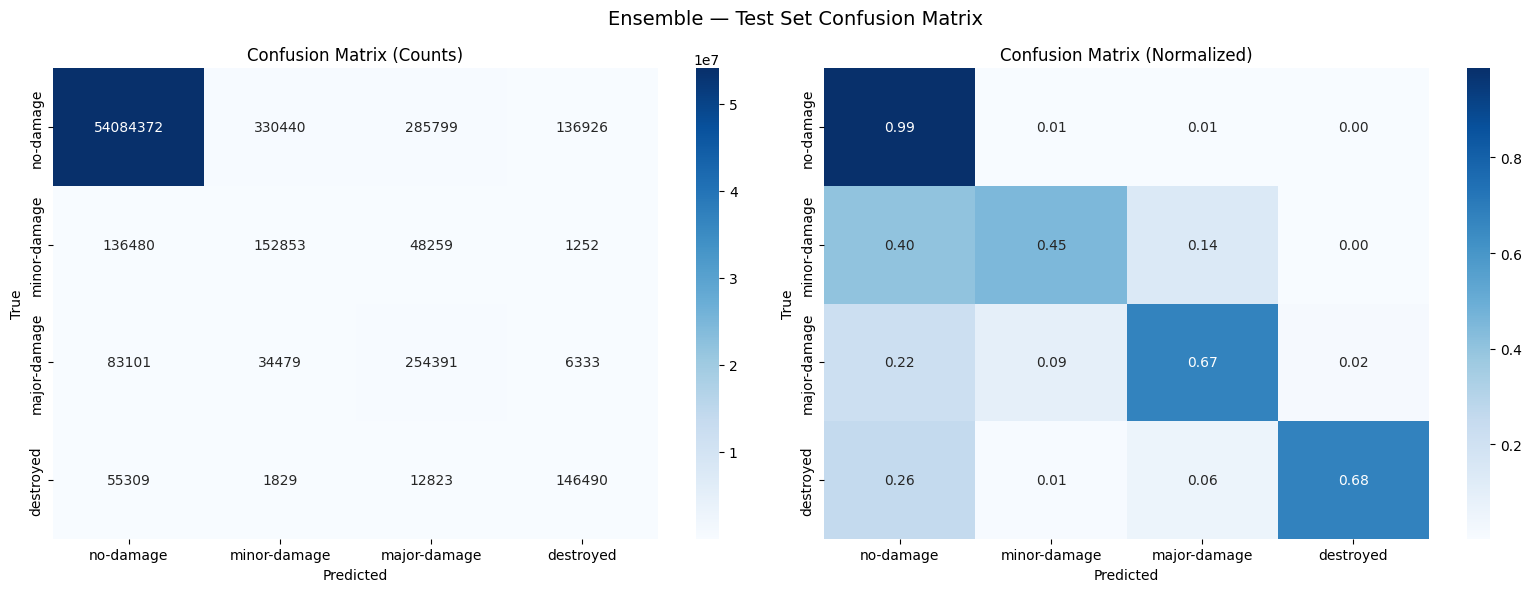

In [7]:
# --- cell 7: confusion matrix --- 

# normalized confusion matrix heatmap
cm_normalized = confusion_mat.astype(float) / (confusion_mat.sum(axis=1, keepdims=True) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# raw counts
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('Ensemble — Test Set Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'ensemble_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

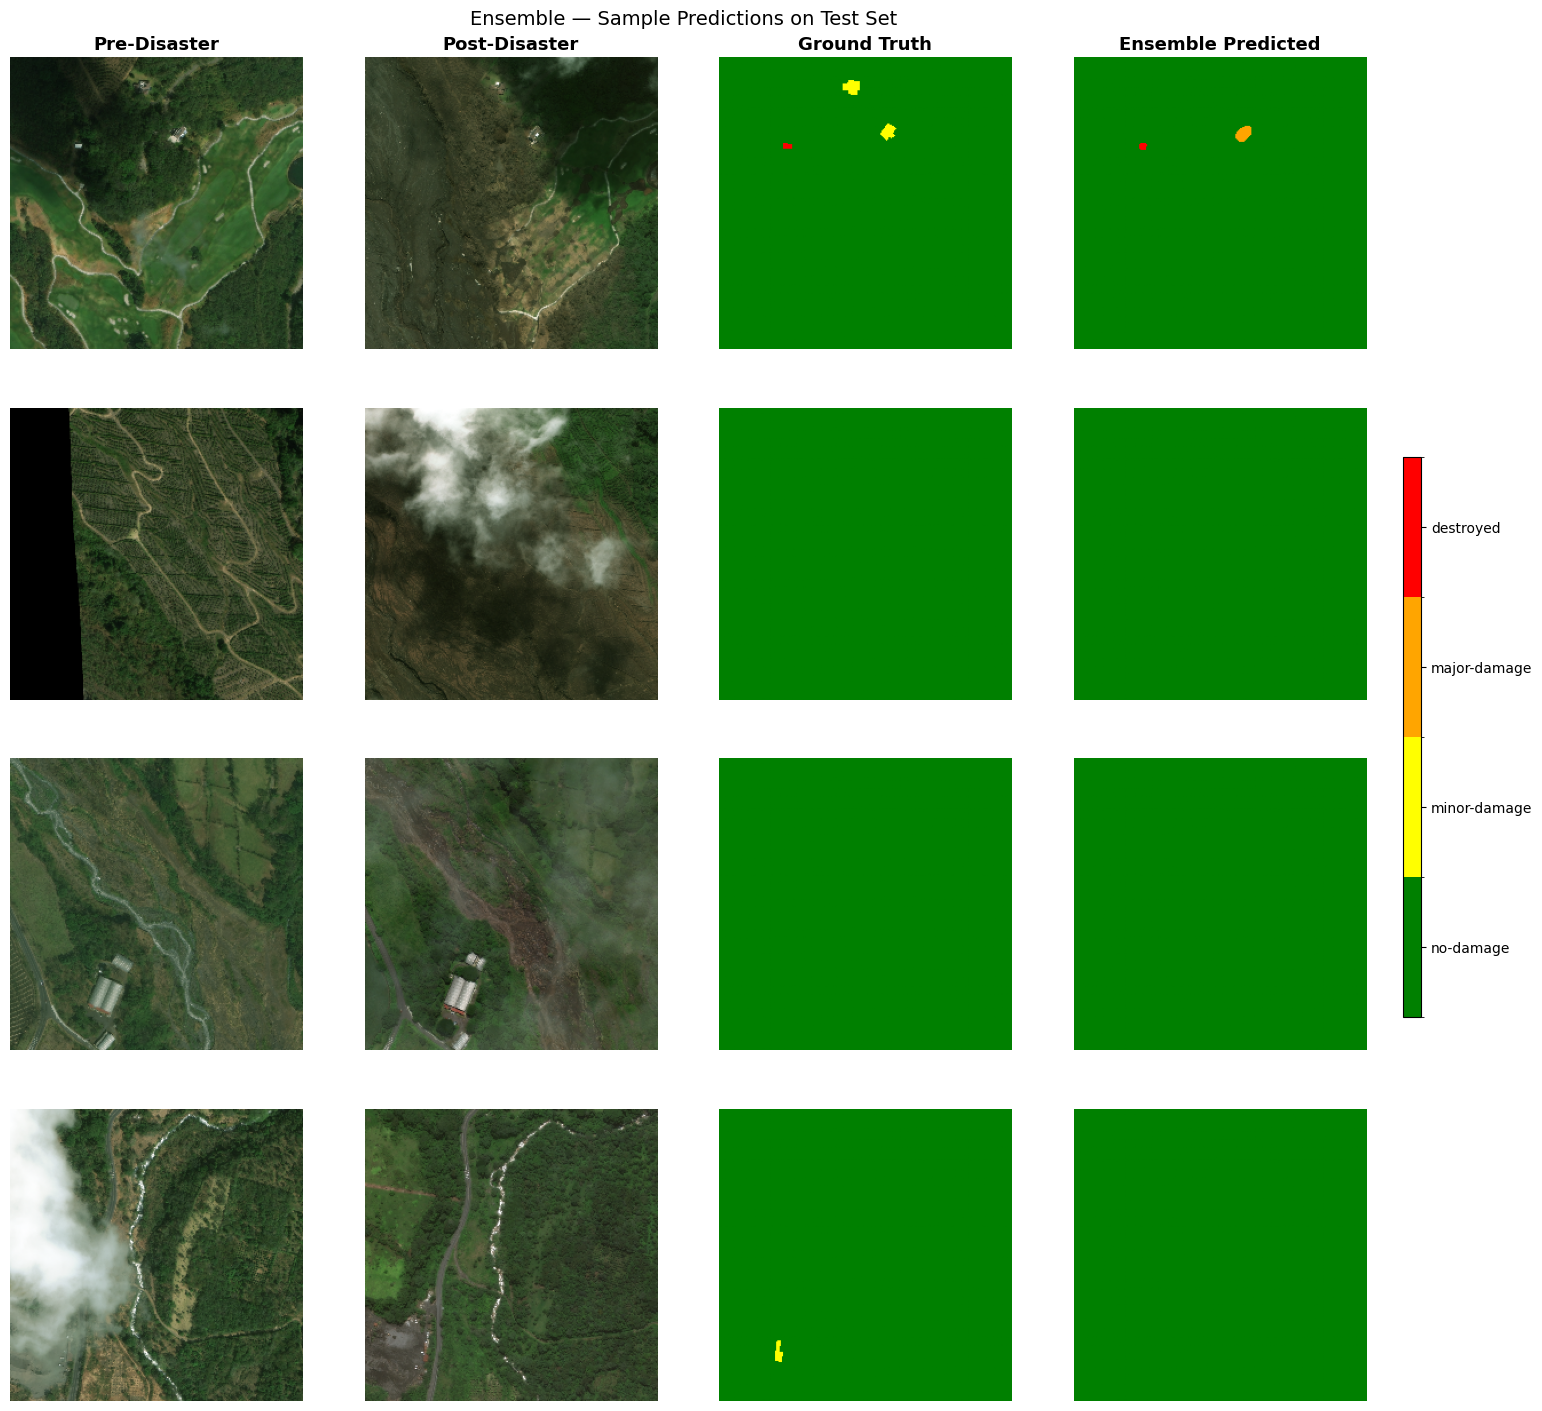

In [12]:
# --- cell 8: sample predictions --- 

# damage class colormap: matches preprocessing labels
# 0=no-damage, 1=minor, 2=major, 3=destroyed
CMAP   = mcolors.ListedColormap(['green', 'yellow', 'orange', 'red'])
BOUNDS = [0, 1, 2, 3, 4]
NORM   = mcolors.BoundaryNorm(BOUNDS, CMAP.N)

def visualize_ensemble_predictions(unet, deeplab, segformer, loader, device, num_samples=4):

    samples_shown = 0
    fig, axes = plt.subplots(num_samples, 4, figsize=(18, num_samples * 4))
    col_titles = ['Pre-Disaster', 'Post-Disaster', 'Ground Truth', 'Ensemble Predicted']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=13, fontweight='bold')

    for pre, post, masks in loader:
        pre   = pre.to(device)
        post  = post.to(device)

        # soft voting ensemble prediction
        avg_probs = ensemble_predict(unet, deeplab, segformer, pre, post)
        preds     = torch.argmax(avg_probs, dim=1).cpu().numpy()
        masks     = masks.numpy()

        for i in range(pre.shape[0]):
            if samples_shown >= num_samples:
                break

            pre_img  = pre[i].cpu().numpy().transpose(1, 2, 0)
            post_img = post[i].cpu().numpy().transpose(1, 2, 0)

            ax_row = axes[samples_shown]

            ax_row[0].imshow(pre_img)
            ax_row[0].axis('off')

            ax_row[1].imshow(post_img)
            ax_row[1].axis('off')

            ax_row[2].imshow(masks[i], cmap=CMAP, norm=NORM)
            ax_row[2].axis('off')

            ax_row[3].imshow(preds[i], cmap=CMAP, norm=NORM)
            ax_row[3].axis('off')

            samples_shown += 1

        if samples_shown >= num_samples:
            break

    # put colorbar to the right without squashing the grid
    fig.subplots_adjust(right=0.88, top=0.95)
    cbar_ax = fig.add_axes([0.90, 0.35, 0.01, 0.35])
    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=NORM)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_ticks([0.5, 1.5, 2.5, 3.5])
    cbar.set_ticklabels(CLASS_NAMES)

    fig.suptitle('Ensemble — Sample Predictions on Test Set', fontsize=14, y=0.98)
    plt.savefig(SAVE_DIR / 'ensemble_sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


visualize_ensemble_predictions(unet, deeplab, segformer, test_loader, DEVICE, num_samples=4)